In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    KernelComponentConfig,
    build_simulation,
)
from kuramoto.analysis import order_parameter
from kuramoto.adjoint import grads_final_R, grads_mean_R
from kuramoto.plotting import plot_2d
from kuramoto.network import create_cortical_graph, plot_cortical_graph

SEED = 42
grid_shape = (16, 16)


# Simple graph
cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(
        mode="spatial",
        kernel="gaussian",
        base_strength=1.0,
        radius=5.0,
        kernel_params={"sigma": 2.0},
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=SEED,
)

sim_simple = build_simulation(config=cfg, rng=np.random.default_rng(SEED))

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

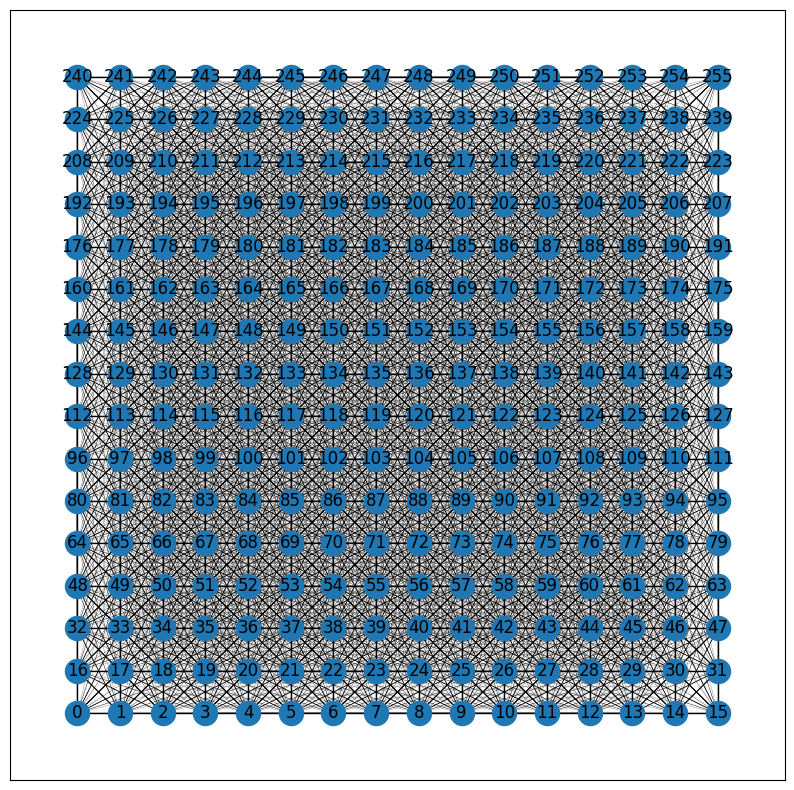

In [ ]:
G = create_cortical_graph(sim_simple)

plot_cortical_graph(G, layout="grid")

### 2) Heterogeneous sim

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

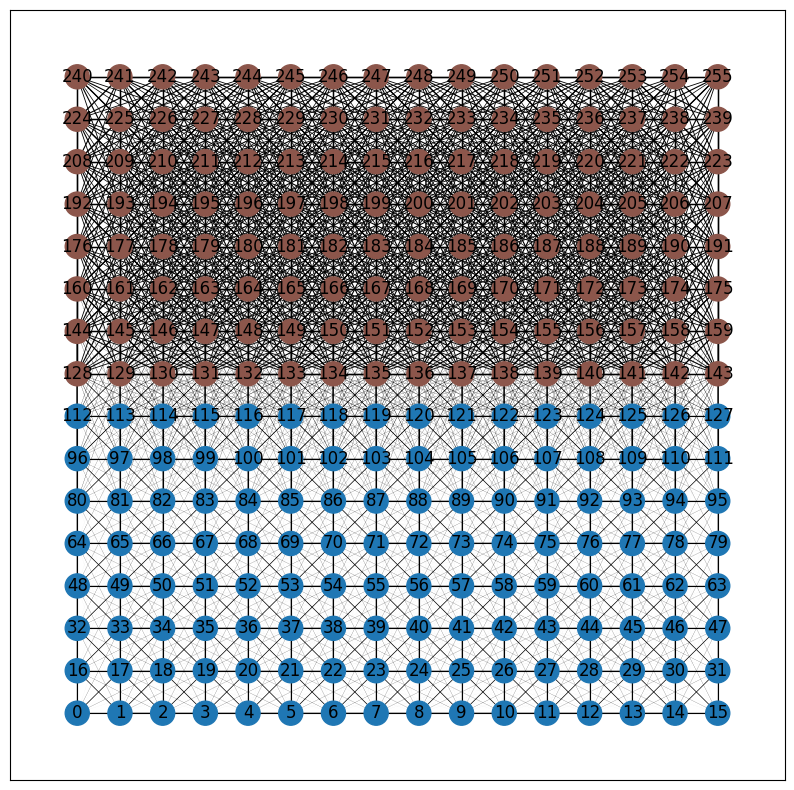

In [ ]:
# Heterogeneous graph
n_rows, n_cols = grid_shape
group_ids = np.zeros((n_rows, n_cols), dtype=int)
group_ids[n_rows // 2 :, :] = 1 # Top half is group 1, bottom half is group 0
group_ids = group_ids.ravel().tolist()

components = [
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=1.0,
        kernel_params={"sigma": 1.0},
        radius=4.0,
        apply_to={"target_groups": [0], "source_groups": [0]},
    ),
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=0.8,
        kernel_params={"sigma": 3.0},
        radius=4.0,
        apply_to={"target_groups": [1], "source_groups": [1]},
    ),
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=0.4,
        kernel_params={"sigma": 2.0},
        radius=4.0,
        apply_to={"target_groups": [0], "source_groups": [1]},
    ),
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=0.4,
        kernel_params={"sigma": 2.0},
        radius=4.0,
        apply_to={"target_groups": [1], "source_groups": [0]},
    ),
]

cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(
        # legacy fields still required by dataclass; hetero uses `components`
        kernel="gaussian",
        base_strength=1.0,
        radius=4.0,
        mode="spatial",
        components=components,
        group_ids=group_ids,
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)

sim_hetero = build_simulation(config=cfg, rng=np.random.default_rng(SEED))

G = create_cortical_graph(sim_hetero)

plot_cortical_graph(G, layout="grid")